<a href="https://colab.research.google.com/github/Ijo2004/Crushathon/blob/main/ML_With_Python_California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of Dataset:
(20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

First 10 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588 

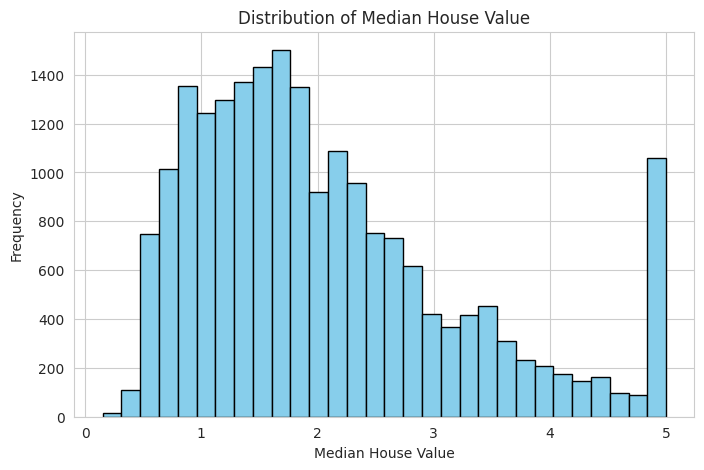

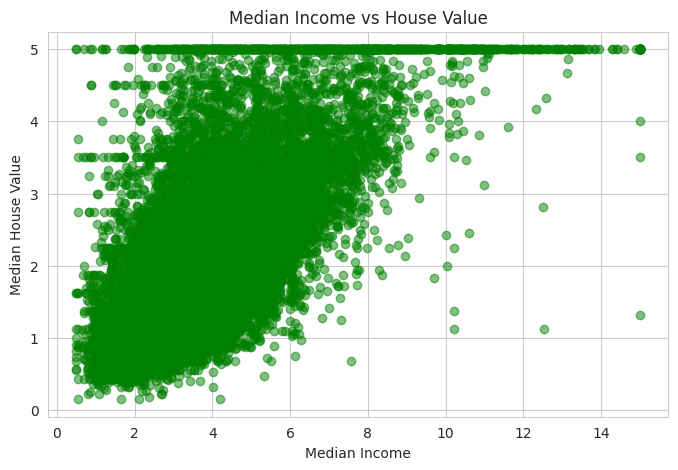

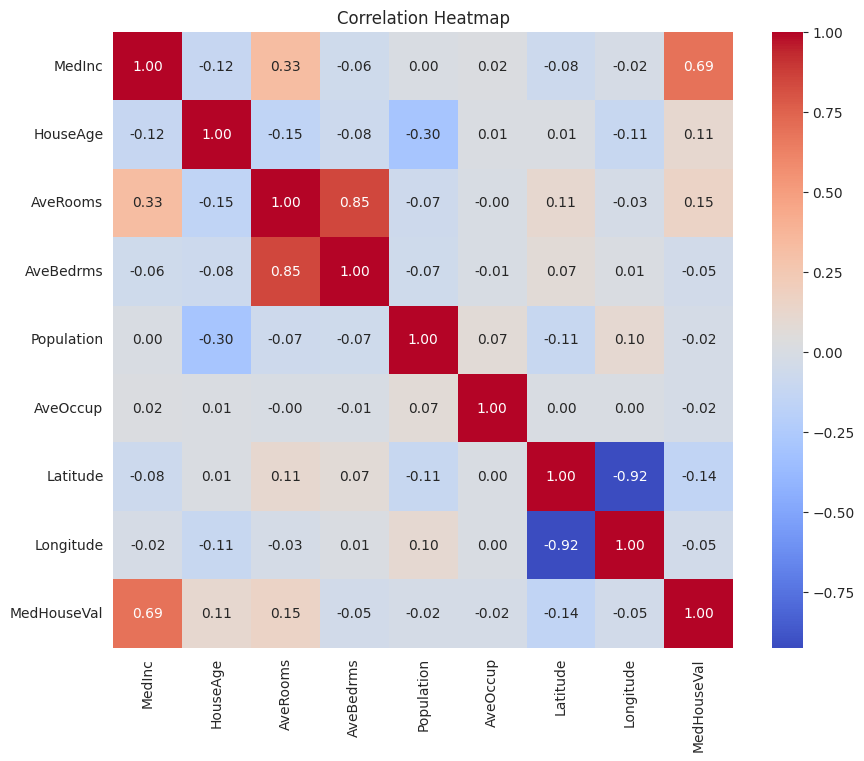

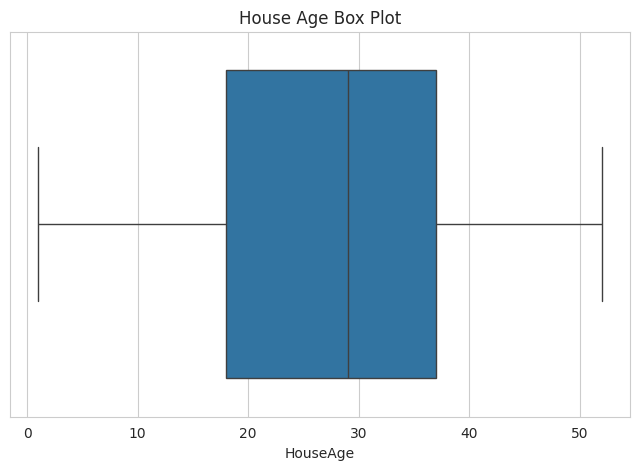

Features Shape: (20640, 8)
Target Shape: (20640,)

Training Data: (16512, 8)
Testing Data: (4128, 8)
Model Training Completed Successfully!
Model Evaluation Results
------------------------------
Mean Squared Error (MSE): 0.5558915986952444
Root Mean Squared Error (RMSE): 0.7455813830127764
R² Score: 0.5757877060324508


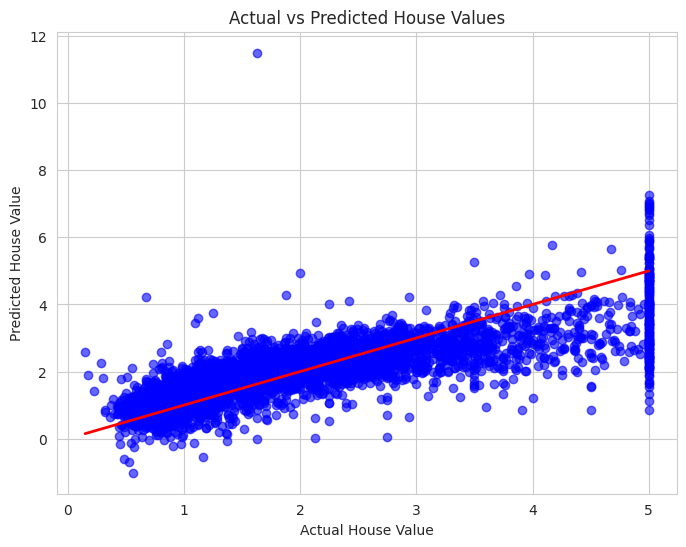

Polynomial Regression Results
-----------------------------------
MSE : 0.4643015261571134
RMSE: 0.6813967465119813
R² Score: 0.6456819711504156
                   Model       MSE      RMSE  R2 Score
0      Linear Regression  0.555892  0.745581  0.575788
1  Polynomial Regression  0.464302  0.681397  0.645682
Predicted Median House Value:
1.541554373372989


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# ==========================
# Step 3: Explore the Dataset
# ==========================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 10 Rows:")
print(df.head(10))

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())
# ==========================
# Step 4: Data Cleaning, Filtering & Aggregation
# ==========================

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# ----------------------------
# Data Filtering
# ----------------------------

# Houses with median income greater than 5
high_income = df[df['MedInc'] > 5]

print("\nHigh Income Houses:")
print(high_income.head())

# ----------------------------
# Data Aggregation
# ----------------------------

# Average house value based on house age
aggregation = df.groupby('HouseAge')['MedHouseVal'].mean()

print("\nAverage House Value by House Age:")
print(aggregation.head(10))
# ==========================
# Step 5: Data Visualization
# ==========================

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# ----------------------------
# 1. Histogram
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

# ----------------------------
# 2. Scatter Plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5, color='green')
plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

# ----------------------------
# 3. Correlation Heatmap
# ----------------------------
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ----------------------------
# 4. Box Plot
# ----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x=df['HouseAge'])
plt.title("House Age Box Plot")
plt.show()
# ==========================
# Step 6: Feature Selection & Train-Test Split
# ==========================

# Features (Input)
X = df.drop("MedHouseVal", axis=1)

# Target (Output)
y = df["MedHouseVal"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Split dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)
# ==========================
# Step 7: Linear Regression Model
# ==========================

# Create Linear Regression Model
model = LinearRegression()

# Train the Model
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)

print("Model Training Completed Successfully!")
# ==========================
# Step 8: Model Evaluation
# ==========================

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
# ==========================
# Actual vs Predicted Graph
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.grid(True)
plt.show()
# ==========================
# Step 9: Polynomial Regression
# ==========================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Create Polynomial Regression Model (Degree = 2)
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

# Train the Model
poly_model.fit(X_train, y_train)

# Predict
poly_pred = poly_model.predict(X_test)

# Evaluation
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial Regression Results")
print("-" * 35)
print("MSE :", poly_mse)
print("RMSE:", poly_rmse)
print("R² Score:", poly_r2)
# ==========================
# Model Comparison
# ==========================

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "MSE": [mse, poly_mse],
    "RMSE": [rmse, poly_rmse],
    "R2 Score": [r2, poly_r2]
})

print(comparison)
# ==========================
# Step 10: Predict on New Data
# ==========================

# Sample New House Data
new_house = pd.DataFrame({
    'MedInc': [3],
    'HouseAge': [20],
    'AveRooms': [6.0],
    'AveBedrms': [1.0],
    'Population': [1200],
    'AveOccup': [3.0],
    'Latitude': [34.2],
    'Longitude': [-118.4]
})

# Predict House Value
predicted_value = model.predict(new_house)

print("Predicted Median House Value:")
print(predicted_value[0])